In [2]:
!pip install bs4

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import bs4 
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

In [5]:
df = pd.read_csv("steam_all_rev.csv", low_memory=False)
#print(df.head())

In [6]:
import datetime
df2 = df.copy()
#Date Cleaning
#df2['release_date'].dtype
#df2['release_date'] = pd.to_datetime(df2['release_date'])
#df2['release_year']= df2['release_date'].dt.year
#print(df2['release_year'])


#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df['release_date'])
#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df.head())


In [4]:
#Platforms:
df2['platforms'].dtype
df2['platforms'] = df2['platforms'].str.split(';')
df2['windows_sup'] = df2['platforms'].apply(lambda x: 1 if 'windows' in x else 0)
df2['mac_sup'] = df2['platforms'].apply(lambda x: 1 if 'mac' in x else 0)
df2['linux_sup'] = df2['platforms'].apply(lambda x: 1 if 'linux' in x else 0)
print(df2.iloc[:,-20:])

      release_date  english           developer             publisher  \
0       2000-11-01        1               Valve                 Valve   
1       2003-05-01        1               Valve                 Valve   
2       1999-11-01        1    Gearbox Software                 Valve   
3       1998-11-08        1               Valve                 Valve   
4       2004-03-01        1               Valve                 Valve   
...            ...      ...                 ...                   ...   
26863   2019-04-24        1         SHEN JIAWEI           SHEN JIAWEI   
26864   2019-04-23        1      Semyon Maximov      BekkerDev Studio   
26865   2019-04-24        1         EntwicklerX           EntwicklerX   
26866   2019-04-17        1  Yustas Game Studio  Alawar Entertainment   
26867   2019-04-24        1    Adept Studios GD  Alawar Entertainment   

                   platforms  required_age  \
0      [windows, mac, linux]             0   
1      [windows, mac, linux]   

In [49]:
import itertools

#Genres
df2['genres'] = df2['genres'].str.split(';')
unique_gen = np.unique([*itertools.chain.from_iterable(df2['genres'])])
print(unique_gen)

for i in unique_gen:
    df2[i+"_genre"] = df2['genres'].apply(lambda x: 1 if i in x else 0)


TypeError: 'float' object is not iterable

In [6]:
#Categories:
df2['categories'] = df2['categories'].str.split(';')
unique_cat = np.unique([*itertools.chain.from_iterable(df2['categories'])])
print(unique_cat)

for i in unique_cat:
    df2[i+"_cat"] = df2['categories'].apply(lambda x: 1 if i in x else 0)

['Captions available' 'Co-op' 'Commentary available'
 'Cross-Platform Multiplayer' 'Full controller support' 'In-App Purchases'
 'Includes Source SDK' 'Includes level editor' 'Local Co-op'
 'Local Multi-Player' 'MMO' 'Mods' 'Mods (require HL2)' 'Multi-player'
 'Online Co-op' 'Online Multi-Player' 'Partial Controller Support'
 'Shared/Split Screen' 'Single-player' 'Stats' 'Steam Achievements'
 'Steam Cloud' 'Steam Leaderboards' 'Steam Trading Cards'
 'Steam Turn Notifications' 'Steam Workshop' 'SteamVR Collectibles'
 'VR Support' 'Valve Anti-Cheat enabled']


In [7]:
print(df2.iloc[:,-60:])

       mac_sup  linux_sup  Accounting_genre  Action_genre  Adventure_genre  \
0            1          1                 0             1                0   
1            1          1                 0             1                0   
2            1          1                 0             1                0   
3            1          1                 0             1                0   
4            1          1                 0             1                0   
...        ...        ...               ...           ...              ...   
26863        0          0                 0             0                1   
26864        0          0                 0             1                1   
26865        0          0                 0             1                0   
26866        1          0                 0             0                1   
26867        1          0                 0             0                1   

       Animation & Modeling_genre  Audio Production_genre  Casu

In [8]:
#check if game has some external support
support_cols = ['website','support_url', 'support_email']
df2['external_supp'] = df2[support_cols].notna().any(axis=1).astype(int)

In [2]:
#Minimum Requirements:
req_df = pd.read_csv("tech_spec.csv")

In [3]:
print(req_df['minimum'].count())
min = pd.DataFrame(req_df['pc_requirements'])
#min.to_csv('min_req.csv')
min
print(min.dtypes)

26864
pc_requirements    str
dtype: object


In [4]:
min_df = min.sample(n=1000)
min_df

,pc_requirements
23995,{'minimum': '<strong>Minimum:</strong><br><ul ...
4227,{'minimum': '<strong>Minimum:</strong><br><ul ...
21086,{'minimum': '<strong>Minimum:</strong><br><ul ...
15796,{'minimum': '<strong>Minimum:</strong><br><ul ...
10997,{'minimum': '<strong>Minimum:</strong><br><ul ...
...,...
2587,{'minimum': '<strong>Minimum:</strong><br><ul ...
881,{'minimum': '<strong>Minimum:</strong><br>\t\t...
22707,{'minimum': '<strong>Minimum:</strong><br><ul ...
8310,{'minimum': '<strong>Minimum:</strong><br><ul ...


In [5]:
#Parse pc-requirements

import ast
import re
from bs4 import BeautifulSoup

def parse_pc_requirements(pc_req_str: str) -> str:
    if pd.isna(pc_req_str) or not isinstance(pc_req_str, str):
        return "NA"
    try:
        parsed = ast.literal_eval(pc_req_str)
    except (ValueError, SyntaxError):
        parsed = {"minimum": pc_req_str}
 
    # Prefer 'minimum'; fall back to 'recommended'
    section = parsed.get("minimum") or parsed.get("recommended", "")
 
    # Strip HTML tags
    text = BeautifulSoup(section, "html.parser").get_text(" ")
 
    # When the minimum value already contains both "Minimum:" and
    # "Recommended:" labels (common in older Steam entries), slice off
    # everything from the "Recommended:" label onward.
    # We match "Recommended:" as a label (preceded by whitespace or start-of-string)
    # to avoid cutting on mid-sentence uses like "(3.0 GHz recommended)".
    min_match = re.search(r"\bminimum\b", text, re.IGNORECASE)
    rec_match = re.search(r"(?:^|\s)recommended\s*:", text, re.IGNORECASE)
    if min_match and rec_match and rec_match.start() > min_match.start():
        text = text[: rec_match.start()]
    return text

min['cleaned'] = min['pc_requirements'].apply(parse_pc_requirements)



In [6]:
min

,pc_requirements,cleaned
0,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb..."
1,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb..."
2,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb..."
3,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb..."
4,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb..."
...,...,...
26866,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 Processor: Inter Core...
26867,{'minimum': '<strong>Minimum:</strong><br><ul ...,"Minimum: OS: Windows XP, Vista, 7, 8, 10 Proc..."
26868,{'minimum': '<strong>Minimum:</strong><br><ul ...,"Minimum: OS: Windows 7, Windows 8, Windows 10..."
26869,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP or later Processor: ...


In [7]:
#Extract processor
def extract_cpu_ghz(text: str) -> float | None:
    """
    Return the first CPU speed found in the text as a float in GHz.
 
    Handles:
    - "1.7 GHz", "800 MHz" (MHz is divided by 1000)
    - European decimal commas: "2,66 GHz" → 2.66
    - GPU model false-positives: "GTX 7970 MHz" is ignored
    """
    # Normalize European decimal comma (e.g. "2,66GHz" → "2.66GHz")
    text = re.sub(r"(\d),(\d)", r"\1.\2", text)
 
    # Remove GPU model number contexts that coincidentally contain MHz/GHz
    # e.g. "GTX 7970 MHz", "HD 7870 MHz"
    text = re.sub(
        r"(?:GTX|RTX|RX|HD|GT|GTS)\s*\d+\s*(?:Ti|XT)?\s*(?:MHz|GHz)",
        "",
        text,
        flags=re.IGNORECASE,
    )
 
    match = re.search(r"(\d+\.?\d*)\s*(ghz|mhz)", text, re.IGNORECASE)
    if not match:
        return None
 
    val = float(match.group(1))
    unit = match.group(2).lower()
    return round(val / 1000, 3) if unit == "mhz" else val

min['processor_Ghz']= min['cleaned'].apply(extract_cpu_ghz)

def clean_cpu_ghz(val):
    if val is None:
        return None
    if val > 20:
        return None
    return val

min['processor_Ghz']= min['processor_Ghz'].apply(clean_cpu_ghz)

In [8]:
min['processor_Ghz']

0        0.5
1        0.5
2        0.5
3        0.5
4        0.5
        ... 
26866    NaN
26867    2.5
26868    2.0
26869    1.5
26870    2.0
Name: processor_Ghz, Length: 26871, dtype: float64

In [9]:
#Extract RAM:
def extract_ram_mb(text: str) -> int | None:
    """
    Return the minimum RAM in MB.
 
    Recognises patterns such as:
    - "512 MB RAM", "2 GB RAM"
    - "Memory: 256 MB"
    """
    # Pattern A: <number> MB/GB RAM  (most common)
    match = re.search(r"(\d+\.?\d*)\s*(gb|mb)\s*ram", text, re.IGNORECASE)
 
    # Pattern B: Memory: <number> MB/GB
    if not match:
        match = re.search(
            r"memory[:\s]+(\d+\.?\d*)\s*(gb|mb)", text, re.IGNORECASE
        )
 
    if not match:
        return None
 
    val = float(match.group(1))
    unit = match.group(2).lower()
    return int(val * 1024) if unit == "gb" else int(val)

min['RAM_mb']= min['cleaned'].apply(extract_ram_mb)


In [22]:
min

,pc_requirements,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb
0,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN
1,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN
2,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN
3,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN
4,{'minimum': '\r\n\t\t\t<p><strong>Minimum:</st...,"\n Minimum: 500 mhz processor, 96mb ram, 16mb...",0.5,96.0,16.0,1,NaN
...,...,...,...,...,...,...,...
26866,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 Processor: Inter Core...,NaN,2048.0,300.0,0,300.0
26867,{'minimum': '<strong>Minimum:</strong><br><ul ...,"Minimum: OS: Windows XP, Vista, 7, 8, 10 Proc...",2.5,4096.0,NaN,0,300.0
26868,{'minimum': '<strong>Minimum:</strong><br><ul ...,"Minimum: OS: Windows 7, Windows 8, Windows 10...",2.0,256.0,1024.0,0,100.0
26869,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP or later Processor: ...,1.5,750.0,512.0,0,500.0


In [21]:
min['RAM_mb']


0          96.0
1          96.0
2          96.0
3          96.0
4          96.0
          ...  
26866    2048.0
26867    4096.0
26868     256.0
26869     750.0
26870    1024.0
Name: RAM_mb, Length: 26871, dtype: float64

In [11]:
#Extract GPU
def extract_gpu_mb(text: str) -> int | None:
    """
    Return the GPU VRAM requirement in MB.

    Two directional patterns, tried in order:
    - Pattern A (number → keyword): "16mb video card", "2 GB VRAM"
    - Pattern B (keyword → number): "Graphics: 128 MB", "DirectX compatible 128 MB graphics card"
    """
    # Pattern A: number+unit immediately followed (within ~3 words) by a GPU keyword
    # This handles "16mb video card", "2GB VRAM"
    match = re.search(
        r"(\d+\.?\d*)\s*(gb|mb)\s*(?:\w+\s*){0,3}?(?:video\s*card|vram|gpu|graphics\s*card)",
        text,
        re.IGNORECASE,
    )

    # Pattern B: GPU keyword followed (within ~60 chars) by a number+unit
    # This handles "Graphics: 128 MB", "DirectX compatible 128 MB graphics card"
    if not match:
        match = re.search(
            r"(?:graphics|video\s*card|vram|gpu)[^,\n]{0,60}?(\d+\.?\d*)\s*(gb|mb)",
            text,
            re.IGNORECASE,
        )

    if not match:
        return None

    val = float(match.group(1))
    unit = match.group(2).lower()
    return int(val * 1024) if unit == "gb" else int(val)

min['GPU_mb']= min['cleaned'].apply(extract_gpu_mb)


In [12]:
min['GPU_mb'].head(20)
#NA's probably originate for games that just say "DirectX..." card.

0       16.0
1       16.0
2       16.0
3       16.0
4       16.0
5       16.0
6     6500.0
7        NaN
8        NaN
9        NaN
10       NaN
11       NaN
12       NaN
13       NaN
14     128.0
15     128.0
16       NaN
17     128.0
18     128.0
19     256.0
Name: GPU_mb, dtype: float64

In [13]:
#Extract internet:
def extract_internet(text: str) -> bool:
    """Return True if an internet connection is mentioned in the text."""
    return int(
        bool(
            re.search(r"internet\s*(connection|access|required)?", text, re.IGNORECASE)
        )
    )

min['internet_required'] = min['cleaned'].apply(extract_internet)

In [14]:
min['internet_required'].head(20)

0     1
1     1
2     1
3     1
4     1
5     1
6     0
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    0
15    0
16    1
17    0
18    0
19    0
Name: internet_required, dtype: int64

In [15]:
#Storage Specs:
def extract_storage_mb(text: str) -> int | None:
    """
    Return required storage space in MB.

    Recognises patterns such as:
    - "10 GB available space"
    - "Storage: 25 GB"
    - "Hard Drive: 2 GB free"
    - "500 MB disk space"

    Anchors to storage-related keywords to avoid picking up RAM values.
    """

    # Pattern A: keyword first → "Storage: 10 GB"
    match = re.search(
        r"(?:storage|hard\s*drive|disk\s*space|hdd|ssd)[^\n]{0,80}?(\d+\.?\d*)\s*(gb|mb)",
        text,
        re.IGNORECASE,
    )

    # Pattern B: number first → "10 GB available space"
    if not match:
        match = re.search(
            r"(\d+\.?\d*)\s*(gb|mb)[^\n]{0,40}(?:available|free|required)?\s*(?:disk|storage|space|hdd|ssd)",
            text,
            re.IGNORECASE,
        )

    if not match:
        return None

    val = float(match.group(1))
    unit = match.group(2).lower()
    return int(val * 1024) if unit == "gb" else int(val)

min['storage_mb'] = min['cleaned'].apply(extract_storage_mb)

In [16]:
min['storage_mb'].head(20)

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
5         NaN
6      6500.0
7         NaN
8         NaN
9         NaN
10        NaN
11        NaN
12        NaN
13    15360.0
14     7680.0
15    13312.0
16    15360.0
17     8192.0
18     2560.0
19    15360.0
Name: storage_mb, dtype: float64

In [32]:
#min['processor_Ghz'].describe()
proc_na = min[min['processor_Ghz'].isna()]
proc_na

,pc_requirements,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb
19,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows® 7/Vista/XP Processor: ...,NaN,2048.0,256.0,0,15360.0
24,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows XP, P3-600-Geforce 2, 12...",NaN,128.0,NaN,1,128.0
36,{'minimum': '<strong>Minimum: </strong>A 100% ...,Minimum: A 100% Windows XP/Vista-compatible c...,NaN,NaN,NaN,0,NaN
54,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows 2000/XP, Pentium III, 25...",NaN,256.0,32.0,0,32.0
55,{'minimum': '<strong>Recommended:</strong> Win...,"Recommended: Windows 2000/XP, Pentium III, 25...",NaN,256.0,32.0,0,32.0
...,...,...,...,...,...,...,...
26860,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7/8/10 Processor: Inte...,NaN,4096.0,6144.0,0,6144.0
26861,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: WindowsXP (Service Pack 3) Proce...,NaN,2048.0,2048.0,0,2048.0
26862,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7+ Processor: Intel i3 ...,NaN,512.0,256.0,0,200.0
26865,{'minimum': '<strong>最低配置:</strong><br><ul cla...,最低配置: 操作系统: Windows 7/8.1/10 处理器: Intel Core...,NaN,512.0,NaN,0,NaN


In [27]:
#Removing outliers in RAM:
upper = min["RAM_mb"].quantile(0.99)

outliers = min[min["RAM_mb"] > upper]

cleaned = min[min["RAM_mb"] <= upper]

min['RAM_mb'] = cleaned['RAM_mb']
min['RAM_mb'].describe()

count    24934.000000
mean      2440.819644
std       2174.380403
min          0.000000
25%       1024.000000
50%       2048.000000
75%       4096.000000
max       8192.000000
Name: RAM_mb, dtype: float64

In [24]:
high_outliers = min[min["RAM_mb"] > min["RAM_mb"].quantile(0.99)]
low_outliers = min[min["RAM_mb"] < min["RAM_mb"].quantile(0.01)]

high_outliers
low_outliers

,pc_requirements,cleaned,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb
3173,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP Processor: 2.0 GHz D...,2.0,1.0,256.0,0,250.0
3229,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP / Vista / 7 / 8 / 10 ...,0.8,2.0,NaN,0,50.0
3586,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 or Windows 8 Processor...,1.8,1.0,128.0,0,80.0
4464,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 and up Memory: 2 MB RAM,NaN,2.0,NaN,0,NaN
4465,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7 Memory: 2 MB RAM,NaN,2.0,NaN,0,NaN
...,...,...,...,...,...,...,...
26156,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows XP/Vista/7/8/10 Processo...,2.0,1.0,300.0,0,300.0
26192,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 98 Processor: Intel 803...,NaN,1.0,NaN,0,1.0
26621,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Windows 7/8 32-bit Processor: Q...,2.5,2.0,500.0,0,500.0
26675,{'minimum': '<strong>Minimum:</strong><br><ul ...,Minimum: OS: Microsoft® Windows® XP or later ...,2.0,1.0,NaN,0,250.0


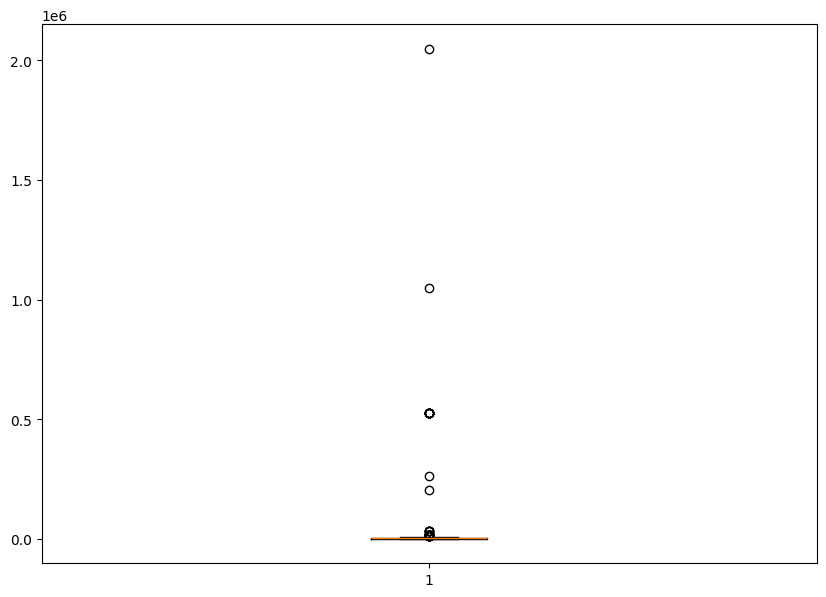

In [20]:
processor_plot= min['RAM_mb'].dropna()
fig = plt.figure(figsize = (10,7))
plt.boxplot(processor_plot)
plt.show()

In [29]:
#Add rating proportion
df2_trimmed['pos_prop'] = (df2_trimmed['positive_ratings']/df2_trimmed['total_reviews'])
print(df2_trimmed['pos_prop'].head())

df2_trimmed['pos_prop'].describe()
#Plot:
sns.histplot((df2_trimmed['pos_prop']))

# Adding labels and title
plt.xlabel('pos_prop')
plt.ylabel('Density')
plt.title('overall_rating_proportions')

# Display the plot
plt.show()


NameError: name 'df2_trimmed' is not defined

In [ ]:
#Removing

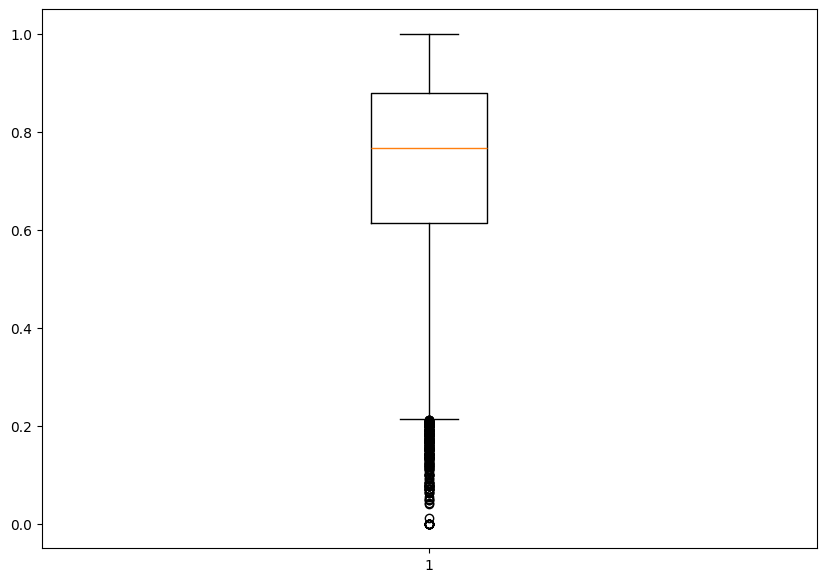

In [14]:
#Boxplot:
pos_prop= df2['pos_prop']
fig = plt.figure(figsize = (10,7))
plt.boxplot(pos_prop)
plt.show()